# 🔍  Eksplorativna analiza podataka (EDA) — Cijene Polovnih Automobila

**Autor:** Adelmina Kaic

## 🎯 1.Cilj analize:
Upoznavanje sa skupom podataka o polovnim automobilima, provjera strukture, analiza nedostajućih i ekstremnih vrijednosti (outlier-a), te analiza ciljne promjenljive (priceUSD). Ova analiza nam pomaže da donesemo ispravne i opravdane odluke za fazu čišćenja i pripreme podataka za mašinsko učenje.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Podešavanje vizuelnog stila za grafikone
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Učitavanje originalnog skupa podataka
df = pd.read_csv('../data/cars.csv')
print("Podaci su uspješno učitani!")

Podaci su uspješno učitani!


## 📊 2. Učitavanje i istraživanje skupa podataka

Pregledamo osnovne dimenzije skupa (broj redova i kolona), prvih nekoliko unosa i tipove podataka u svakoj koloni.

In [35]:
# Dimenzije skupa podataka
print(f"Broj redova: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")

# Pregled prvih 5 redova
df.head()

Broj redova: 56244
Broj kolona: 12


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  segment              50953 non-null  str    
dtypes: float64(2), int64(2), str(8)
memory usage: 8.3 MB


Zapažanja o strukturi:

Dataset sadrži preko 56.000 unosa i 12 kolona.

Podaci kombinuju numeričke kolone (year, mileage, volume, priceUSD) i kategoričke kolone (make, model, fuel_type, transmission, drive_unit, segment, itd.).

## ❓ 3. Analiza nedostajućih vrijednosti (Missing Values)

Provjeravamo u kojim kolonama postoje prazne vrijednosti i u kojem procentu, kako bismo odredili odgovarajuću strategiju imputacije u src/data_cleaning.py.

In [37]:
# Prebrojavanje i procenat praznih vrijednosti po kolonama
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Broj nedostajućih': missing_data, 'Procenat (%)': missing_percent})
missing_df[missing_df['Broj nedostajućih'] > 0].sort_values(by='Broj nedostajućih', ascending=False)

,Broj nedostajućih,Procenat (%)
segment,5291,9.407226
drive_unit,1905,3.387028
volume(cm3),47,0.083564


Zapažanja i odluka za čišćenje:

Najviše praznih unosa imaju kolone drive_unit i segment, dok volume ima manji broj nedostajućih vrijednosti.

Strategija: Zbog očuvanja veličine skupa podataka, tekstualne praznine popunjavamo sa 'unknown', dok numeričke popunjavamo medijanom.



## 🎯 4. Analiza ciljne promjenljive (priceUSD)

Analiziramo raspodjelu cijena automobila koje naš model treba da predvidi.

In [38]:
# Osnovna deskriptivna statistika za cijenu
df['priceUSD'].describe()

count     56244.000000
mean       7415.456440
std        8316.959261
min          48.000000
25%        2350.000000
50%        5350.000000
75%        9807.500000
max      235235.000000
Name: priceUSD, dtype: float64

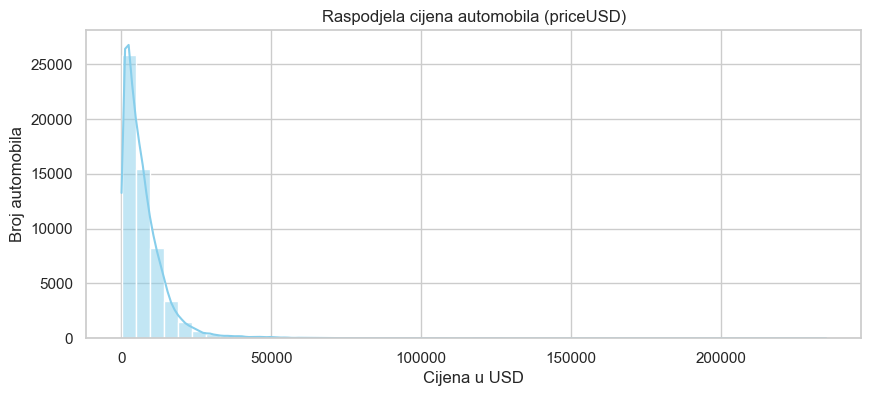

In [39]:
# Histogram raspodjele cijena
plt.figure(figsize=(10, 4))
sns.histplot(df['priceUSD'], bins=50, kde=True, color='skyblue')
plt.title('Raspodjela cijena automobila (priceUSD)')
plt.xlabel('Cijena u USD')
plt.ylabel('Broj automobila')
plt.show()

## 📝Zapažanja o cijeni:

Raspodjela cijena je pozitivno zakrivljena — većina polovnih automobila se prodaje u rasponu od $1.000 do $15.000.

Prisutan je manji broj izuzetno skupih automobila koji odskaču od ostatka skupa.

## 🔢 5. Analiza numeričkih kolona
Provjeravamo statistiku i raspodjelu ključnih numeričkih obilježja: year (godište), mileage (kilometraža) i volume (kubikaža).
Standardizujemo kolone radi lakseg rukovanja podatcima.

In [40]:
# Prikaz statistike za numeričke kolone
df[['year', 'mileage(kilometers)', 'volume(cm3)']].describe()

df.columns = (
        df.columns.str.lower()
        .str.strip()
        .str.replace('(', '', regex=False)
        .str.replace(')', '', regex=False)
        .str.replace(' ', '_', regex=False)
    )

df = df.rename(columns={
        'mileagekilometers': 'mileage',
        'volumecm3': 'volume'
    })

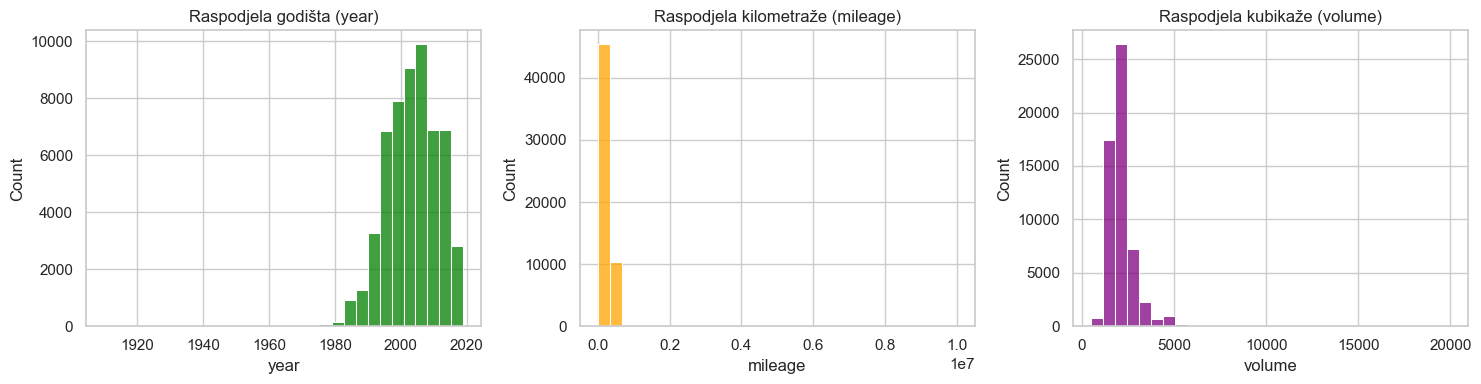

In [41]:
# Histogrami za numeričke kolone
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['year'], bins=30, ax=axes[0], color='green')
axes[0].set_title('Raspodjela godišta (year)')

sns.histplot(df['mileage'], bins=30, ax=axes[1], color='orange')
axes[1].set_title('Raspodjela kilometraže (mileage)')

sns.histplot(df['volume'], bins=30, ax=axes[2], color='purple')
axes[2].set_title('Raspodjela kubikaže (volume)')

plt.tight_layout()
plt.show()

## 🏷️ 6. Analiza kategorijskih kolona
Provjeravamo najčešće marke automobila (make), vrstu goriva (fuel_type) i tip mjenjača (

C:\Users\user\AppData\Local\Temp\ipykernel_17224\4068777431.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.index, y=top_makes.values, palette='viridis')


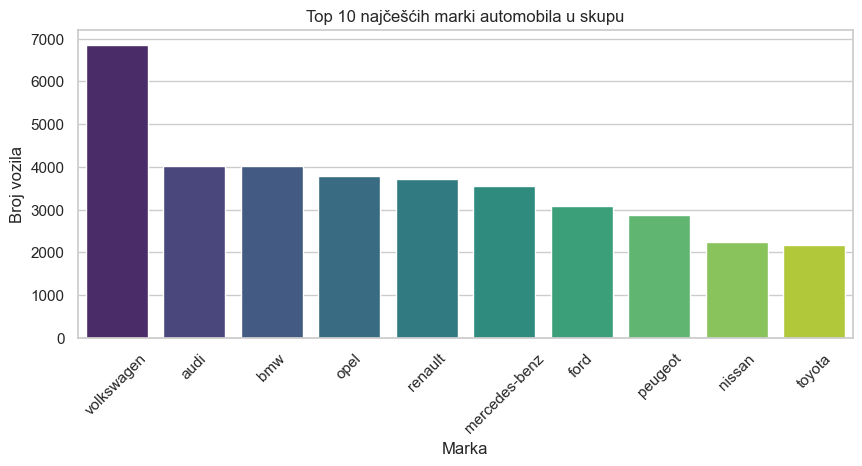

In [42]:
# Prikaz 10 najčešćih marki automobila
plt.figure(figsize=(10, 4))
top_makes = df['make'].value_counts().head(10)
sns.barplot(x=top_makes.index, y=top_makes.values, palette='viridis')
plt.title('Top 10 najčešćih marki automobila u skupu')
plt.xlabel('Marka')
plt.ylabel('Broj vozila')
plt.xticks(rotation=45)
plt.show()

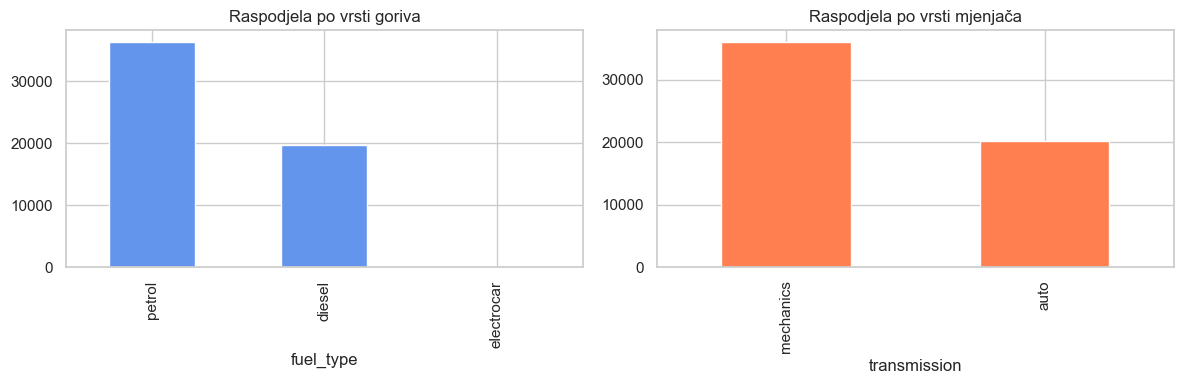

In [43]:
# Raspodjela goriva i mjenjača
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['fuel_type'].value_counts().plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Raspodjela po vrsti goriva')

df['transmission'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Raspodjela po vrsti mjenjača')

plt.tight_layout()
plt.show()

## 🚨 7. Detekcija ekstremnih vrijednosti (Outliers)

Pomoću Boxplot grafikona identifikujemo nerealne i ekstremne vrijednosti koje mogu negativno uticati na treniranje modela.

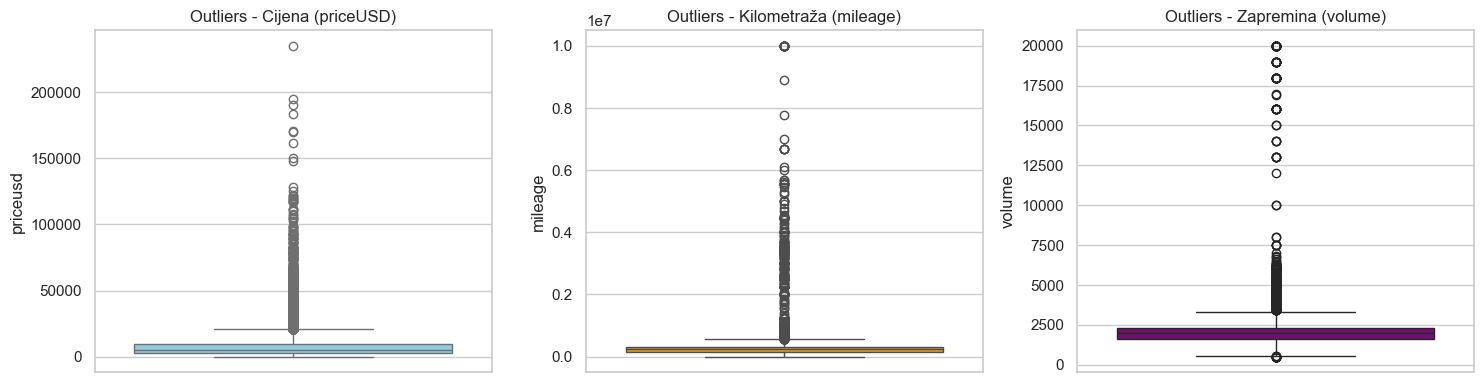

In [45]:
# Boxplot prikazi za detekciju autlajera
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df['priceusd'], ax=axes[0], color='skyblue')
axes[0].set_title('Outliers - Cijena (priceUSD)')

sns.boxplot(y=df['mileage'], ax=axes[1], color='orange')
axes[1].set_title('Outliers - Kilometraža (mileage)')

sns.boxplot(y=df['volume'], ax=axes[2], color='purple')
axes[2].set_title('Outliers - Zapremina (volume)')

plt.tight_layout()
plt.show()

## 🏆 8. Poređenje i izbor najboljeg modela

Nakon pripreme podataka i testiranja više regresionih algoritama, uporedili smo njihove performanse na testnom skupu pomoću tri ključne metrike: MAE, RMSE i $R^2$.

In [46]:
# Tabela sa konačnim rezultatima evaluacije
results_data = {
    'Model': ['Random Forest Regressor', 'Gradient Boosting Regressor', 'Decision Tree Regressor', 'Linear Regression'],
    'MAE ($)': [978.02, 1375.21, 1297.02, 2030.18],
    'RMSE ($)': [2108.49, 2519.46, 2776.90, 3695.41],
    'R² Score': [0.9222, 0.8889, 0.8651, 0.7611]
}

df_results = pd.DataFrame(results_data)
df_results.sort_values(by='R² Score', ascending=False, inplace=True)
df_results.reset_index(drop=True, inplace=True)
df_results

,Model,MAE ($),RMSE ($),R² Score
0,Random Forest Regressor,978.02,2108.49,0.9222
1,Gradient Boosting Regressor,1375.21,2519.46,0.8889
2,Decision Tree Regressor,1297.02,2776.90,0.8651
3,Linear Regression,2030.18,3695.41,0.7611


## 📌 9. Zaključak i izbor finalnog modela


Izabrani šampionski model: `Random Forest Regressor`
Zašto baš ovaj model? 
1. Najveća tačnost ($R^2 = 0.9222$): Model objašnjava preko 92% varijacije u cijenama automobila, što ga čini znatno superiornijim u odnosu na ostale algoritme.
2. Najmanja greška (MAE = $978.02): Prosječno odstupanje predviđene cijene je ispod $1.000.
Sposobnost učenja nelinearnih odnosa:
 Odlično se nosi sa složenim interakcijama između starosti vozila, brenda i pređene kilometraže.